# Volunteer Testing - Thermal Emotion Recognition Model Evaluation

This notebook extracts frames from volunteer videos and evaluates the **Grid Search optimized model** (`thermal_emotion_model_gridsearch.h5`) on real volunteer data.

## Process:
1. Extract frames from emotion videos (Angry, Happy, Natural, Sad, Surprise)
2. Save frames to organized folders per volunteer and emotion
3. Test extracted frames using the trained model
4. Generate comprehensive accuracy reports per volunteer and emotion

## 1. Import Required Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import defaultdict
import joblib

print("All libraries imported successfully")

All libraries imported successfully


## 2. Configuration and Paths

In [2]:
# Paths configuration
BASE_DIR = r"d:\R&I_ThermalCameras\AccuracyEvaluation"
MODEL_PATH = r"d:\R&I_ThermalCameras\thermal_emotion_model_gridsearch.h5"

# Model parameters
IMG_SIZE = (128, 128)
FRAME_SKIP = 5  # Extract every 5th frame to avoid redundant similar frames

# Volunteer folders
VOLUNTEERS = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6']

# Emotion video names
EMOTIONS = {
    'Angry': 'Angry.mp4',
    'Happy': 'Happy.mp4',
    'Natural': 'Natural.mp4',
    'Sad': 'Sad.mp4',
    'Surprise': 'Suprise.mp4'  
}

# note: 'surpise' typo from training data)
# Training used: ['angry', 'happy', 'natural', 'sad', 'surpise']
CLASS_LABELS = ['angry', 'happy', 'natural', 'sad', 'surpise']  # to match training

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Base Directory: {BASE_DIR}")
print(f"Model Path: {MODEL_PATH}")
print(f"Image Size: {IMG_SIZE}")
print(f"Frame Skip: Every {FRAME_SKIP} frames")
print(f"Volunteers: {len(VOLUNTEERS)}")
print(f"Emotions: {list(EMOTIONS.keys())}")
print(f"Class Labels as trainied: {CLASS_LABELS}")
print("="*70)


CONFIGURATION
Base Directory: d:\R&I_ThermalCameras\AccuracyEvaluation
Model Path: d:\R&I_ThermalCameras\thermal_emotion_model_gridsearch.h5
Image Size: (128, 128)
Frame Skip: Every 5 frames
Volunteers: 6
Emotions: ['Angry', 'Happy', 'Natural', 'Sad', 'Surprise']
Class Labels as trainied: ['angry', 'happy', 'natural', 'sad', 'surpise']


## 3. Load Trained Model

In [3]:
print("="*70)
print("LOADING GRID SEARCH MODEL...")
print("="*70)

model = load_model(MODEL_PATH)
print(f"Model loaded successfully from: {MODEL_PATH}")
print(f"\nModel Summary:")
model.summary()

print("\n" + "="*70)
print(f"Expected Performance (from training):")
print(f"  - Validation Accuracy: 91.15%")
print(f"  - F1 Score (Macro): ~0.91")
print("="*70)

LOADING GRID SEARCH MODEL...
Model loaded successfully from: d:\R&I_ThermalCameras\thermal_emotion_model_gridsearch.h5

Model Summary:


Model: "sequential_98"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_294 (Conv2D)             │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_294               │ (None, 63, 63, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_295 (Conv2D)             │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_295               │ (None, 30, 30, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_296 (Conv2D)             │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_296               │ (None, 14, 14, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_98 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_196 (Dense)               │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_197 (Dense)               │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,287 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


Expected Performance (from training):
  - Validation Accuracy: 91.15%
  - F1 Score (Macro): ~0.91


## 4. Frame Extraction Function

In [4]:
def extract_frames_from_video(video_path, output_folder, emotion_name, frame_skip=5):
    """
    Extract frames from a video file and save them to the output folder.
    
    Parameters:
    -----------
    video_path : str
        Path to the video file
    output_folder : str
        Directory where frames will be saved
    emotion_name : str
        Name of the emotion (for naming frames)
    frame_skip : int
        Extract every Nth frame (default: 5)
    
    Returns:
    --------
    int : Number of frames extracted
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return 0
    
    # Get video properties
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    print(f"   Video: {os.path.basename(video_path)}")
    print(f"   Total frames: {total_frames}, FPS: {fps:.2f}")
    
    frame_count = 0
    saved_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Extract every Nth frame
        if frame_count % frame_skip == 0:
            frame_filename = f"{emotion_name}_frame_{saved_count:04d}.jpg"
            frame_path = os.path.join(output_folder, frame_filename)
            cv2.imwrite(frame_path, frame)
            saved_count += 1
        
        frame_count += 1
    
    cap.release()
    print(f"   Extracted {saved_count} frames (every {frame_skip}th frame)")
    
    return saved_count

print("Frame extraction function defined")

Frame extraction function defined


## 5. Extract Frames from All Volunteer Videos

In [5]:
print("="*70)
print("EXTRACTING FRAMES FROM VOLUNTEER VIDEOS")
print("="*70)

extraction_summary = {}

for volunteer in VOLUNTEERS:
    volunteer_path = os.path.join(BASE_DIR, volunteer)
    
    if not os.path.exists(volunteer_path):
        print(f"Skipping {volunteer} - folder not found")
        continue
    
    print(f"\n{'='*70}")
    print(f"Processing: {volunteer}")
    print(f"{'='*70}")
    
    volunteer_frames = {}
    
    for emotion_name, video_filename in EMOTIONS.items():
        video_path = os.path.join(volunteer_path, video_filename)
        
        if not os.path.exists(video_path):
            print(f"Video not found: {video_filename}")
            continue
        
        # Create emotion folder inside volunteer folder
        emotion_folder = os.path.join(volunteer_path, emotion_name)
        
        print(f"\n{emotion_name}:")
        num_frames = extract_frames_from_video(
            video_path, 
            emotion_folder, 
            emotion_name.lower(),
            frame_skip=FRAME_SKIP
        )
        
        volunteer_frames[emotion_name] = num_frames
    
    extraction_summary[volunteer] = volunteer_frames

print("\n" + "="*70)
print("EXTRACTION SUMMARY")
print("="*70)

for volunteer, emotions in extraction_summary.items():
    print(f"\n{volunteer}:")
    total = 0
    for emotion, count in emotions.items():
        print(f"  {emotion:12s}: {count:4d} frames")
        total += count
    print(f"  {'TOTAL':12s}: {total:4d} frames")

print("="*70)
print("Frame extraction complete!")
print("="*70)

EXTRACTING FRAMES FROM VOLUNTEER VIDEOS

Processing: Sub1

Angry:
   Video: Angry.mp4
   Total frames: 236, FPS: 25.00
   Extracted 48 frames (every 5th frame)

Happy:
   Video: Happy.mp4
   Total frames: 321, FPS: 25.00
   Extracted 65 frames (every 5th frame)

Natural:
   Video: Natural.mp4
   Total frames: 240, FPS: 25.00
   Extracted 48 frames (every 5th frame)

Sad:
   Video: Sad.mp4
   Total frames: 701, FPS: 25.00
   Extracted 141 frames (every 5th frame)

Surprise:
   Video: Suprise.mp4
   Total frames: 338, FPS: 25.00
   Extracted 68 frames (every 5th frame)

Processing: Sub2

Angry:
   Video: Angry.mp4
   Total frames: 272, FPS: 25.00
   Extracted 55 frames (every 5th frame)

Happy:
   Video: Happy.mp4
   Total frames: 221, FPS: 25.00
   Extracted 45 frames (every 5th frame)

Natural:
   Video: Natural.mp4
   Total frames: 217, FPS: 25.00
   Extracted 44 frames (every 5th frame)

Sad:
   Video: Sad.mp4
   Total frames: 644, FPS: 25.00
   Extracted 129 frames (every 5th frame)

## 6. Prediction Function

In [ ]:
def predict_emotion(image_path, model, img_size=(128, 128)):

    try:
        # Load and preprocess image
        img = cv2.imread(image_path)
        if img is None:
            return None, None, None
        
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)
        
        # Predict
        probs = model.predict(img, verbose=0)[0]
        pred_idx = np.argmax(probs)
        pred_label = CLASS_LABELS[pred_idx]
        confidence = probs[pred_idx]
        
        return pred_label, confidence, probs
    
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None, None, None

print("Prediction function defined")

Prediction function defined


## 7. Test Model on Extracted Frames (Organized by Emotion)

In [7]:
print("="*70)
print("TESTING MODEL ON EXTRACTED FRAMES")
print("Organized by EMOTION across all volunteers")
print("="*70)

# Store all predictions
all_predictions = []
all_true_labels = []
all_confidences = []

# Per-emotion results across all volunteers
emotion_results = {}

# Per-volunteer results (for comparison)
volunteer_results = {}

# Mapping from folder names to model labels (handles 'Surprise' -> 'surpise' typo)
EMOTION_TO_LABEL = {
    'Angry': 'angry',
    'Happy': 'happy',
    'Natural': 'natural',
    'Sad': 'sad',
    'Surprise': 'surpise'  # Maps folder 'Surprise' to model's 'surpise'
}

# Test emotion-by-emotion across all volunteers
for emotion_name in EMOTIONS.keys():
    true_label = EMOTION_TO_LABEL[emotion_name]  # Get correct model label
    
    print(f"\n{'='*70}")
    print(f"Testing Emotion: {emotion_name.upper()}")
    print(f"{'='*70}")
    
    emotion_preds = []
    emotion_true = []
    emotion_conf = []
    emotion_total_frames = 0
    emotion_correct = 0
    
    # Collect frames from all volunteers for this emotion
    for volunteer in VOLUNTEERS:
        volunteer_path = os.path.join(BASE_DIR, volunteer)
        emotion_folder = os.path.join(volunteer_path, emotion_name)
        
        if not os.path.exists(emotion_folder):
            continue
        
        # Get all frame images
        frame_files = [f for f in os.listdir(emotion_folder) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not frame_files:
            continue
        
        print(f"  {volunteer}: Testing {len(frame_files)} frames...")
        
        volunteer_correct = 0
        
        for frame_file in frame_files:
            frame_path = os.path.join(emotion_folder, frame_file)
            pred_label, confidence, probs = predict_emotion(frame_path, model, IMG_SIZE)
            
            if pred_label is None:
                continue
            
            # Store results
            all_predictions.append(pred_label)
            all_true_labels.append(true_label)
            all_confidences.append(confidence)
            
            emotion_preds.append(pred_label)
            emotion_true.append(true_label)
            emotion_conf.append(confidence)
            
            if pred_label == true_label:
                emotion_correct += 1
                volunteer_correct += 1
        
        volunteer_accuracy = (volunteer_correct / len(frame_files)) * 100 if frame_files else 0
        print(f"     Accuracy: {volunteer_accuracy:.2f}% ({volunteer_correct}/{len(frame_files)})")
        emotion_total_frames += len(frame_files)
    
    # Calculate emotion-level accuracy
    if emotion_total_frames > 0:
        emotion_accuracy = (emotion_correct / emotion_total_frames) * 100
        emotion_results[emotion_name] = {
            'accuracy': emotion_accuracy,
            'total_frames': emotion_total_frames,
            'correct': emotion_correct,
            'predictions': emotion_preds,
            'true_labels': emotion_true,
            'confidences': emotion_conf
        }
        
        print(f"\n  {emotion_name.upper()} OVERALL: {emotion_accuracy:.2f}% ({emotion_correct}/{emotion_total_frames} frames)")
    else:
        print(f"\n  No frames found for {emotion_name}")

print("\n" + "="*70)
print("Testing complete!")
print("="*70)


TESTING MODEL ON EXTRACTED FRAMES
Organized by EMOTION across all volunteers

Testing Emotion: ANGRY
  Sub1: Testing 48 frames...
     Accuracy: 0.00% (0/48)
  Sub2: Testing 55 frames...
     Accuracy: 0.00% (0/55)
  Sub3: Testing 73 frames...
     Accuracy: 0.00% (0/73)
  Sub4: Testing 42 frames...
     Accuracy: 0.00% (0/42)
  Sub5: Testing 44 frames...
     Accuracy: 4.55% (2/44)
  Sub6: Testing 37 frames...
     Accuracy: 0.00% (0/37)

  ANGRY OVERALL: 0.67% (2/299 frames)

Testing Emotion: HAPPY
  Sub1: Testing 65 frames...
     Accuracy: 20.00% (13/65)
  Sub2: Testing 45 frames...
     Accuracy: 0.00% (0/45)
  Sub3: Testing 53 frames...
     Accuracy: 0.00% (0/53)
  Sub4: Testing 36 frames...
     Accuracy: 5.56% (2/36)
  Sub5: Testing 40 frames...
     Accuracy: 0.00% (0/40)
  Sub6: Testing 33 frames...
     Accuracy: 0.00% (0/33)

  HAPPY OVERALL: 5.51% (15/272 frames)

Testing Emotion: NATURAL
  Sub1: Testing 48 frames...
     Accuracy: 100.00% (48/48)
  Sub2: Testing 44 frame

## 8. Overall Performance Metrics

In [8]:
print("="*70)
print("OVERALL PERFORMANCE METRICS")
print("="*70)

# Calculate overall accuracy
overall_accuracy = accuracy_score(all_true_labels, all_predictions) * 100
avg_confidence = np.mean(all_confidences) * 100

print(f"\nTotal Frames Tested: {len(all_predictions)}")
print(f"Overall Accuracy: {overall_accuracy:.2f}%")
print(f"Average Confidence: {avg_confidence:.2f}%")

print("\n" + "="*70)
print("PER-EMOTION SUMMARY (Across All Volunteers)")
print("="*70)
print(f"{'Emotion':<12} {'Accuracy':<12} {'Correct':<10} {'Total':<10} {'Avg Conf'}")
print("-"*70)

for emotion_name, results in emotion_results.items():
    avg_conf = np.mean(results['confidences']) * 100 if results['confidences'] else 0
    print(f"{emotion_name:<12} {results['accuracy']:>6.2f}%     "
          f"{results['correct']:>6}/{results['total_frames']:<6} "
          f"{avg_conf:>6.2f}%")

print("="*70)

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(all_true_labels, all_predictions, target_names=CLASS_LABELS))
print("="*70)

OVERALL PERFORMANCE METRICS

Total Frames Tested: 1542
Overall Accuracy: 18.94%
Average Confidence: 74.29%

PER-EMOTION SUMMARY (Across All Volunteers)
Emotion      Accuracy     Correct    Total      Avg Conf
----------------------------------------------------------------------
Angry          0.67%          2/299     71.54%
Happy          5.51%         15/272     71.63%
Natural       34.50%         89/258     76.28%
Sad           29.59%        129/436     76.06%
Surprise      20.58%         57/277     75.20%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.67      0.01      0.01       299
       happy       0.44      0.06      0.10       272
     natural       0.13      0.34      0.18       258
         sad       0.37      0.30      0.33       436
     surpise       0.13      0.21      0.16       277

    accuracy                           0.19      1542
   macro avg       0.35      0.18      0.16      1542
weighted avg       0.35     

## 9. Confusion Matrix Visualization

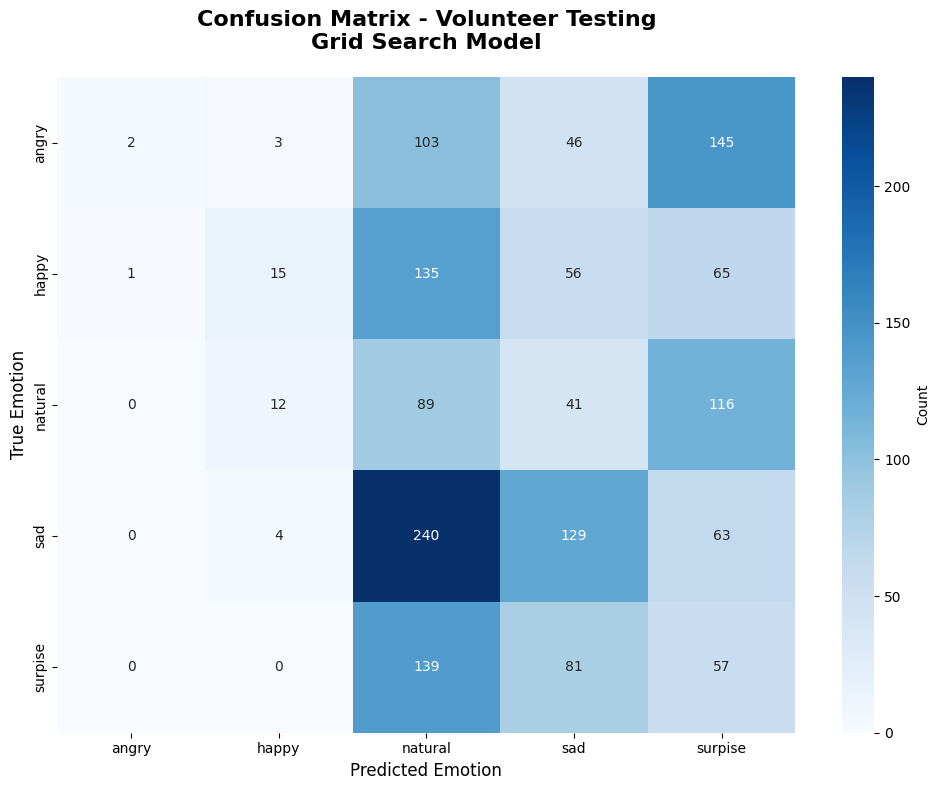

Confusion matrix saved as 'confusion_matrix_volunteer_testing.png'


In [9]:
# Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions, labels=CLASS_LABELS)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Volunteer Testing\nGrid Search Model', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix_volunteer_testing.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix_volunteer_testing.png'")

## 10. Per-Emotion Accuracy Visualization

PER-EMOTION PERFORMANCE BREAKDOWN


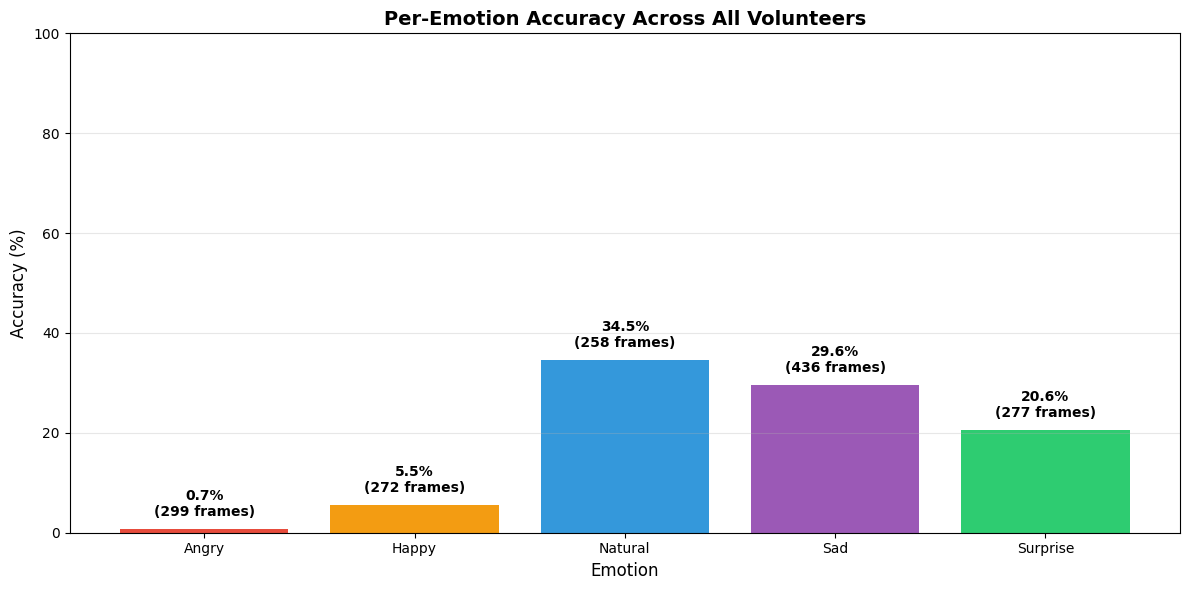

Per-emotion accuracy chart saved as 'per_emotion_accuracy.png'


In [10]:
# Use emotion_results data for visualization
print("="*70)
print("PER-EMOTION PERFORMANCE BREAKDOWN")
print("="*70)

# Plot per-emotion accuracy
emotions_list = list(emotion_results.keys())
accuracies = [emotion_results[e]['accuracy'] for e in emotions_list]
frame_counts = [emotion_results[e]['total_frames'] for e in emotions_list]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(emotions_list)), accuracies, color=['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#2ecc71'])
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Emotion Accuracy Across All Volunteers', fontsize=14, fontweight='bold')
plt.xticks(range(len(emotions_list)), [e.capitalize() for e in emotions_list])
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars with frame counts
for i, (bar, acc, count) in enumerate(zip(bars, accuracies, frame_counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{acc:.1f}%\n({count} frames)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'per_emotion_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Per-emotion accuracy chart saved as 'per_emotion_accuracy.png'")

## 11. Emotion Confusion Analysis

In [ ]:
# Analyze which emotions are confused with each other
print("="*70)
print("EMOTION CONFUSION ANALYSIS")
print("="*70)

for emotion_name, results in emotion_results.items():
    true_label = emotion_name.lower()
    preds = results['predictions']
    
    # Count misclassifications
    misclassified = {}
    for pred in preds:
        if pred != true_label:
            misclassified[pred] = misclassified.get(pred, 0) + 1
    
    if misclassified:
        total_wrong = sum(misclassified.values())
        print(f"\n{emotion_name.upper()}:")
        print(f"  Correct: {results['correct']}/{results['total_frames']} ({results['accuracy']:.1f}%)")
        print(f"  Most confused with:")
        
        # Sort by frequency
        sorted_conf = sorted(misclassified.items(), key=lambda x: x[1], reverse=True)
        for confused_emotion, count in sorted_conf[:3]:  # Top 3
            pct = (count / results['total_frames']) * 100
            print(f"    - {confused_emotion.capitalize()}: {count} times ({pct:.1f}%)")
    else:
        print(f"\n{emotion_name.upper()}: Perfect accuracy!")

print("\n" + "="*70)

EMOTION CONFUSION ANALYSIS

ANGRY:
  Correct: 2/299 (0.7%)
  Most confused with:
    - Surpise: 145 times (48.5%)
    - Natural: 103 times (34.4%)
    - Sad: 46 times (15.4%)

HAPPY:
  Correct: 15/272 (5.5%)
  Most confused with:
    - Natural: 135 times (49.6%)
    - Surpise: 65 times (23.9%)
    - Sad: 56 times (20.6%)

NATURAL:
  Correct: 89/258 (34.5%)
  Most confused with:
    - Surpise: 116 times (45.0%)
    - Sad: 41 times (15.9%)
    - Happy: 12 times (4.7%)

SAD:
  Correct: 129/436 (29.6%)
  Most confused with:
    - Natural: 240 times (55.0%)
    - Surpise: 63 times (14.4%)
    - Happy: 4 times (0.9%)

SURPRISE:
  Correct: 57/277 (20.6%)
  Most confused with:
    - Natural: 139 times (50.2%)
    - Sad: 81 times (29.2%)
    - Surpise: 57 times (20.6%)



## 12. Sample Predictions Summary

In [12]:
# Show prediction statistics per emotion
print("="*70)
print("PREDICTION STATISTICS BY EMOTION")
print("="*70)

for emotion_name, results in emotion_results.items():
    correct_count = results['correct']
    total_count = results['total_frames']
    incorrect_count = total_count - correct_count
    
    print(f"\n{emotion_name.upper()}:")
    print(f"  Correct predictions: {correct_count}/{total_count} ({results['accuracy']:.1f}%)")
    print(f"  Incorrect predictions: {incorrect_count}/{total_count}")
    
    if results['confidences']:
        avg_conf = np.mean(results['confidences']) * 100
        print(f"  Average confidence: {avg_conf:.2f}%")

print("\n" + "="*70)

PREDICTION STATISTICS BY EMOTION

ANGRY:
  Correct predictions: 2/299 (0.7%)
  Incorrect predictions: 297/299
  Average confidence: 71.54%

HAPPY:
  Correct predictions: 15/272 (5.5%)
  Incorrect predictions: 257/272
  Average confidence: 71.63%

NATURAL:
  Correct predictions: 89/258 (34.5%)
  Incorrect predictions: 169/258
  Average confidence: 76.28%

SAD:
  Correct predictions: 129/436 (29.6%)
  Incorrect predictions: 307/436
  Average confidence: 76.06%

SURPRISE:
  Correct predictions: 57/277 (20.6%)
  Incorrect predictions: 220/277
  Average confidence: 75.20%



## 13. Export Results to CSV

In [13]:
# Create emotion-based summary DataFrame
emotion_summary = pd.DataFrame({
    'Emotion': [e.capitalize() for e in emotion_results.keys()],
    'Accuracy (%)': [round(emotion_results[e]['accuracy'], 2) for e in emotion_results.keys()],
    'Total Frames': [emotion_results[e]['total_frames'] for e in emotion_results.keys()],
    'Correct Predictions': [emotion_results[e]['correct'] for e in emotion_results.keys()],
    'Incorrect Predictions': [emotion_results[e]['total_frames'] - emotion_results[e]['correct'] for e in emotion_results.keys()],
    'Avg Confidence (%)': [round(np.mean(emotion_results[e]['confidences']) * 100, 2) for e in emotion_results.keys()]
})

# Add overall row
overall_row = pd.DataFrame({
    'Emotion': ['OVERALL'],
    'Accuracy (%)': [round(overall_accuracy, 2)],
    'Total Frames': [len(all_predictions)],
    'Correct Predictions': [sum([emotion_results[e]['correct'] for e in emotion_results.keys()])],
    'Incorrect Predictions': [len(all_predictions) - sum([emotion_results[e]['correct'] for e in emotion_results.keys()])],
    'Avg Confidence (%)': [round(avg_confidence, 2)]
})

emotion_summary = pd.concat([emotion_summary, overall_row], ignore_index=True)

# Save to CSV
emotion_csv_path = os.path.join(BASE_DIR, 'emotion_testing_results.csv')
emotion_summary.to_csv(emotion_csv_path, index=False)

print("="*70)
print("EMOTION-BASED TESTING RESULTS")
print("="*70)
print(emotion_summary.to_string(index=False))
print("="*70)
print(f"Results saved to: {emotion_csv_path}")
print("="*70)

EMOTION-BASED TESTING RESULTS
 Emotion  Accuracy (%)  Total Frames  Correct Predictions  Incorrect Predictions  Avg Confidence (%)
   Angry          0.67           299                    2                    297           71.540001
   Happy          5.51           272                   15                    257           71.629997
 Natural         34.50           258                   89                    169           76.279999
     Sad         29.59           436                  129                    307           76.059998
Surprise         20.58           277                   57                    220           75.199997
 OVERALL         18.94          1542                  292                   1250           74.290001
Results saved to: d:\R&I_ThermalCameras\AccuracyEvaluation\emotion_testing_results.csv


## 14. Final Summary Report

In [14]:
print("\n" + "="*70)
print("FINAL EVALUATION SUMMARY")
print("="*70)
print(f"\nModel: thermal_emotion_model_gridsearch.h5")
print(f"Test Dataset: {len(VOLUNTEERS)} volunteers, {len(EMOTIONS)} emotions")
print(f"Total Frames Tested: {len(all_predictions)}")
print(f"\n{'='*70}")
print("PERFORMANCE METRICS")
print("="*70)
print(f"Overall Accuracy: {overall_accuracy:.2f}%")
print(f"Average Confidence: {avg_confidence:.2f}%")

print(f"\n{'='*70}")
print("BEST/WORST PERFORMING EMOTIONS")
print("="*70)

# Best/worst emotions
best_emotion = max(emotion_results.items(), key=lambda x: x[1]['accuracy'])
worst_emotion = min(emotion_results.items(), key=lambda x: x[1]['accuracy'])

print(f"Best Emotion: {best_emotion[0].capitalize()} ({best_emotion[1]['accuracy']:.2f}%)")
print(f"  - {best_emotion[1]['correct']}/{best_emotion[1]['total_frames']} frames correct")
print(f"\nWorst Emotion: {worst_emotion[0].capitalize()} ({worst_emotion[1]['accuracy']:.2f}%)")
print(f"  - {worst_emotion[1]['correct']}/{worst_emotion[1]['total_frames']} frames correct")

print(f"\n{'='*70}")
print("FILES GENERATED")
print("="*70)
print("confusion_matrix_volunteer_testing.png")
print("per_emotion_accuracy.png")
print("emotion_testing_results.csv")
print("Extracted frames in Sub1-Sub6 emotion folders")

print(f"\n{'='*70}")
print("EMOTION-BASED TESTING COMPLETE!")
print("="*70)


FINAL EVALUATION SUMMARY

Model: thermal_emotion_model_gridsearch.h5
Test Dataset: 6 volunteers, 5 emotions
Total Frames Tested: 1542

PERFORMANCE METRICS
Overall Accuracy: 18.94%
Average Confidence: 74.29%

BEST/WORST PERFORMING EMOTIONS
Best Emotion: Natural (34.50%)
  - 89/258 frames correct

Worst Emotion: Angry (0.67%)
  - 2/299 frames correct

FILES GENERATED
confusion_matrix_volunteer_testing.png
per_emotion_accuracy.png
emotion_testing_results.csv
Extracted frames in Sub1-Sub6 emotion folders

EMOTION-BASED TESTING COMPLETE!


## 15. Fine-Tune Model on Volunteer Data

In [15]:
# Import additional required libraries for fine-tuning
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import shutil

print("="*70)
print("PREPARING DATA FOR FINE-TUNING")
print("="*70)

# Mapping from folder names to model labels (handles 'Surprise' -> 'surpise' typo)
EMOTION_TO_LABEL = {
    'Angry': 'angry',
    'Happy': 'happy',
    'Natural': 'natural',
    'Sad': 'sad',
    'Surprise': 'surpise'  # Maps folder 'Surprise' to model's 'surpise'
}

# Collect all extracted frames with labels
image_paths = []
labels = []

for volunteer in VOLUNTEERS:
    volunteer_path = os.path.join(BASE_DIR, volunteer)
    
    for emotion_name in EMOTIONS.keys():
        emotion_folder = os.path.join(volunteer_path, emotion_name)
        
        if not os.path.exists(emotion_folder):
            continue
        
        # Get all frame images
        frame_files = [f for f in os.listdir(emotion_folder) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for frame_file in frame_files:
            frame_path = os.path.join(emotion_folder, frame_file)
            image_paths.append(frame_path)
            labels.append(EMOTION_TO_LABEL[emotion_name])  # Use correct model label

print(f"Total images collected: {len(image_paths)}")
print(f"Label distribution:")
for emotion in CLASS_LABELS:
    count = labels.count(emotion)
    print(f"  {emotion.capitalize()}: {count} images")

print("="*70)


PREPARING DATA FOR FINE-TUNING
Total images collected: 1542
Label distribution:
  Angry: 299 images
  Happy: 272 images
  Natural: 258 images
  Sad: 436 images
  Surpise: 277 images


## 16. Create Train/Validation Split

In [16]:
print("="*70)
print("CREATING TRAIN/VALIDATION SPLIT")
print("="*70)

# Split data (80% train, 20% validation)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")

# Create directory structure for fine-tuning
finetune_dir = os.path.join(BASE_DIR, "finetune_data")
train_dir = os.path.join(finetune_dir, "train")
val_dir = os.path.join(finetune_dir, "val")

# Create emotion subdirectories
for emotion in CLASS_LABELS:
    os.makedirs(os.path.join(train_dir, emotion), exist_ok=True)
    os.makedirs(os.path.join(val_dir, emotion), exist_ok=True)

print(f"\nOrganizing images into directory structure...")

# Copy training images
for img_path, label in zip(train_paths, train_labels):
    dest_dir = os.path.join(train_dir, label)
    dest_path = os.path.join(dest_dir, os.path.basename(img_path))
    shutil.copy2(img_path, dest_path)

# Copy validation images
for img_path, label in zip(val_paths, val_labels):
    dest_dir = os.path.join(val_dir, label)
    dest_path = os.path.join(dest_dir, os.path.basename(img_path))
    shutil.copy2(img_path, dest_path)

print("Data organized successfully!")
print(f"Directory: {finetune_dir}")
print("="*70)

CREATING TRAIN/VALIDATION SPLIT
Training samples: 1233
Validation samples: 309

Organizing images into directory structure...
Data organized successfully!
Directory: d:\R&I_ThermalCameras\AccuracyEvaluation\finetune_data


## 17. Setup Data Generators with Augmentation

In [17]:
print("="*70)
print("SETTING UP DATA AUGMENTATION")
print("="*70)

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Validation data generator (no augmentation, only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode='categorical',
    classes=CLASS_LABELS,  # Explicitly specify the 5 classes to match model
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode='categorical',
    classes=CLASS_LABELS,  # Explicitly specify the 5 classes to match model
    shuffle=False
)

print(f"\nTraining batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")
print(f"Classes: {train_generator.class_indices}")
print("="*70)

SETTING UP DATA AUGMENTATION
Found 405 images belonging to 5 classes.
Found 220 images belonging to 5 classes.

Training batches: 13
Validation batches: 7
Classes: {'angry': 0, 'happy': 1, 'natural': 2, 'sad': 3, 'surpise': 4}


## 18. Configure Fine-Tuning Settings

In [ ]:
print("="*70)
print("CONFIGURING FINE-TUNING SETTINGS")
print("="*70)

# Unfreeze the last few layers for fine-tuning
# Firstnmodel architecture
print(f"\nModel has {len(model.layers)} layers")

# Freeze early layers, unfreeze last layers
freeze_until_layer = len(model.layers) - 5  # Unfreeze last 5 layers

for i, layer in enumerate(model.layers):
    if i < freeze_until_layer:
        layer.trainable = False
    else:
        layer.trainable = True
        print(f"Unfrozen: Layer {i} - {layer.name}")

# Compile model with lower learning rate for fine-tuning
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nTrainable parameters: {sum([np.prod(layer.get_weights()[0].shape) for layer in model.layers if layer.trainable and len(layer.get_weights()) > 0])}")
print("="*70)

CONFIGURING FINE-TUNING SETTINGS

Model has 10 layers
Unfrozen: Layer 5 - max_pooling2d_296
Unfrozen: Layer 6 - flatten_98
Unfrozen: Layer 7 - dense_196
Unfrozen: Layer 8 - dropout_98
Unfrozen: Layer 9 - dense_197

Trainable parameters: 3211904


## 19. Fine-Tune the Model

In [19]:
print("="*70)
print("STARTING FINE-TUNING")
print("="*70)

# Setup callbacks
finetuned_model_path = os.path.join(BASE_DIR, "thermal_emotion_model_finetuned.h5")

callbacks = [
    ModelCheckpoint(
        finetuned_model_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Fine-tune the model
epochs = 30

print(f"\nStarting fine-tuning for {epochs} epochs...")
print(f"Best model will be saved to: {finetuned_model_path}\n")

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("FINE-TUNING COMPLETE!")
print("="*70)

STARTING FINE-TUNING

Starting fine-tuning for 30 epochs...
Best model will be saved to: d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5



C:\Users\srikr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.2246 - loss: 4.7063
Epoch 1: val_accuracy improved from None to 0.25909, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 591ms/step - accuracy: 0.2198 - loss: 4.6595 - val_accuracy: 0.2591 - val_loss: 4.1688 - learning_rate: 1.0000e-04
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.1968 - loss: 4.2917
Epoch 2: val_accuracy improved from 0.25909 to 0.28636, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.2025 - loss: 4.1531 - val_accuracy: 0.2864 - val_loss: 3.8738 - learning_rate: 1.0000e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.2129 - loss: 3.7815
Epoch 3: val_accuracy did not improve from 0.28636
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.2321 - loss: 3.6978 - val_accuracy: 0.2864 - val_loss: 3.5842 - learning_rate: 1.0000e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2450 - loss: 3.5838
Epoch 4: val_accuracy improved from 0.28636 to 0.29545, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.3210 - loss: 1.6314 - val_accuracy: 0.3591 - val_loss: 1.5446 - learning_rate: 1.0000e-04
Epoch 27/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.3038 - loss: 1.5997
Epoch 27: val_accuracy improved from 0.35909 to 0.38182, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.3457 - loss: 1.5571 - val_accuracy: 0.3818 - val_loss: 1.5395 - learning_rate: 1.0000e-04
Epoch 28/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.3522 - loss: 1.5574
Epoch 28: val_accuracy improved from 0.38182 to 0.40000, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.3704 - loss: 1.5701 - val_accuracy: 0.4000 - val_loss: 1.5299 - learning_rate: 1.0000e-04
Epoch 29/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3101 - loss: 1.6075
Epoch 29: val_accuracy improved from 0.40000 to 0.40909, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.3259 - loss: 1.6001 - val_accuracy: 0.4091 - val_loss: 1.5275 - learning_rate: 1.0000e-04
Epoch 30/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.3991 - loss: 1.5053
Epoch 30: val_accuracy improved from 0.40909 to 0.41364, saving model to d:\R&I_ThermalCameras\AccuracyEvaluation\thermal_emotion_model_finetuned.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.3728 - loss: 1.5251 - val_accuracy: 0.4136 - val_loss: 1.5225 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.

FINE-TUNING COMPLETE!


## 20. Visualize Fine-Tuning Results

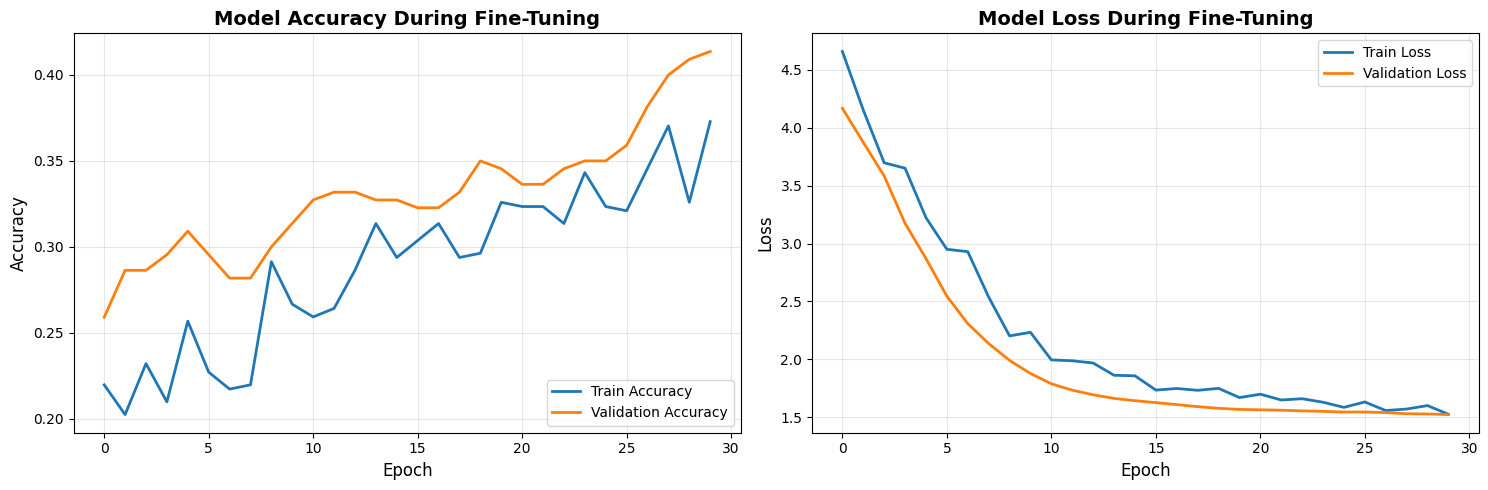

FINE-TUNING RESULTS
Best Epoch: 30
Best Validation Accuracy: 41.36%
Training Accuracy at Best Epoch: 37.28%
Original Model Accuracy: 18.94%
Improvement: 22.43%


In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy During Fine-Tuning', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss During Fine-Tuning', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'finetuning_history.png'), dpi=300, bbox_inches='tight')
plt.show()

# Display best results
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_train_acc = history.history['accuracy'][best_epoch]

print("="*70)
print("FINE-TUNING RESULTS")
print("="*70)
print(f"Best Epoch: {best_epoch + 1}")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Training Accuracy at Best Epoch: {best_train_acc*100:.2f}%")
print(f"Original Model Accuracy: {overall_accuracy:.2f}%")
print(f"Improvement: {(best_val_acc*100 - overall_accuracy):.2f}%")
print("="*70)

## 21. Test Fine-Tuned Model

In [21]:
print("="*70)
print("TESTING FINE-TUNED MODEL ON ALL DATA")
print("="*70)

# Load the best fine-tuned model
finetuned_model = load_model(finetuned_model_path)

# Test on all extracted frames
finetuned_predictions = []
finetuned_confidences = []

print("\nRunning predictions with fine-tuned model...")

for img_path, true_label in zip(image_paths, labels):
    pred_label, confidence, probs = predict_emotion(img_path, finetuned_model, IMG_SIZE)
    
    if pred_label is not None:
        finetuned_predictions.append(pred_label)
        finetuned_confidences.append(confidence)

# Calculate fine-tuned model accuracy
finetuned_accuracy = accuracy_score(labels, finetuned_predictions) * 100
finetuned_avg_conf = np.mean(finetuned_confidences) * 100

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"Original Model Accuracy: {overall_accuracy:.2f}%")
print(f"Fine-Tuned Model Accuracy: {finetuned_accuracy:.2f}%")
print(f"Improvement: {(finetuned_accuracy - overall_accuracy):.2f}%")
print(f"\nOriginal Avg Confidence: {avg_confidence:.2f}%")
print(f"Fine-Tuned Avg Confidence: {finetuned_avg_conf:.2f}%")
print("="*70)

# Detailed classification report
print("\n" + "="*70)
print("FINE-TUNED MODEL CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels, finetuned_predictions, target_names=CLASS_LABELS))
print("="*70)

TESTING FINE-TUNED MODEL ON ALL DATA

Running predictions with fine-tuned model...

MODEL COMPARISON
Original Model Accuracy: 18.94%
Fine-Tuned Model Accuracy: 37.94%
Improvement: 19.00%

Original Avg Confidence: 74.29%
Fine-Tuned Avg Confidence: 32.13%

FINE-TUNED MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.52      0.18      0.27       299
       happy       0.26      0.33      0.29       272
     natural       0.34      0.31      0.33       258
         sad       0.42      0.82      0.55       436
     surpise       1.00      0.01      0.02       277

    accuracy                           0.38      1542
   macro avg       0.51      0.33      0.29      1542
weighted avg       0.50      0.38      0.32      1542



## 22. Compare Confusion Matrices

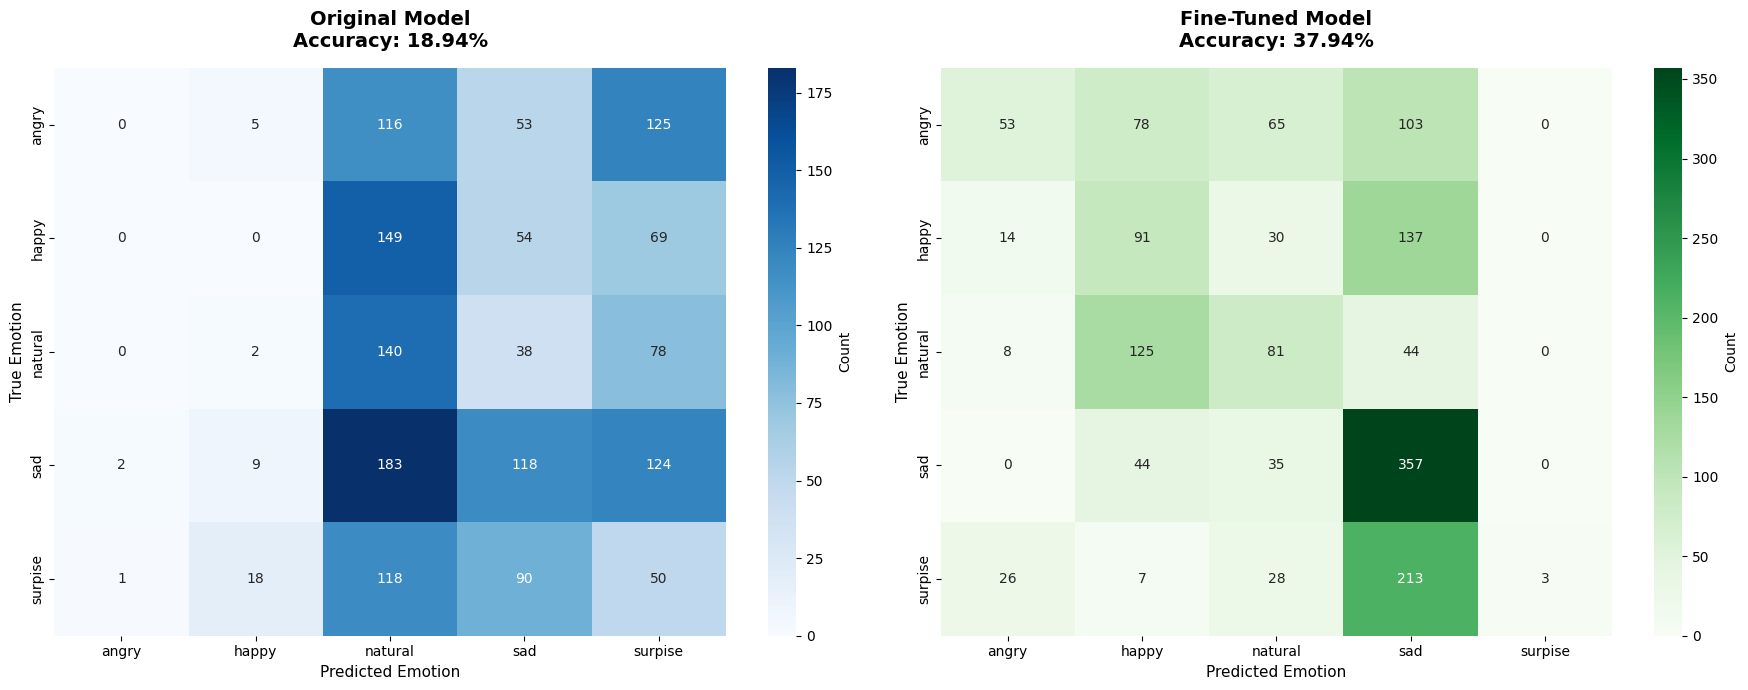

Confusion matrix comparison saved as 'confusion_matrix_comparison.png'


In [22]:
# Compare confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Original model confusion matrix
cm_original = confusion_matrix(labels, all_predictions[:len(labels)], labels=CLASS_LABELS)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title(f'Original Model\nAccuracy: {overall_accuracy:.2f}%', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicted Emotion', fontsize=11)
axes[0].set_ylabel('True Emotion', fontsize=11)

# Fine-tuned model confusion matrix
cm_finetuned = confusion_matrix(labels, finetuned_predictions, labels=CLASS_LABELS)
sns.heatmap(cm_finetuned, annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            cbar_kws={'label': 'Count'}, ax=axes[1])
axes[1].set_title(f'Fine-Tuned Model\nAccuracy: {finetuned_accuracy:.2f}%', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Predicted Emotion', fontsize=11)
axes[1].set_ylabel('True Emotion', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix comparison saved as 'confusion_matrix_comparison.png'")

## 23. Save Fine-Tuning Summary

In [23]:
# Create comparison summary
comparison_df = pd.DataFrame({
    'Metric': ['Overall Accuracy (%)', 'Average Confidence (%)', 'Total Samples'],
    'Original Model': [round(overall_accuracy, 2), round(avg_confidence, 2), len(all_predictions)],
    'Fine-Tuned Model': [round(finetuned_accuracy, 2), round(finetuned_avg_conf, 2), len(finetuned_predictions)],
    'Improvement': [
        round(finetuned_accuracy - overall_accuracy, 2),
        round(finetuned_avg_conf - avg_confidence, 2),
        0
    ]
})

comparison_csv = os.path.join(BASE_DIR, 'model_comparison_summary.csv')
comparison_df.to_csv(comparison_csv, index=False)

print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)
print(f"Summary saved to: {comparison_csv}")

print("\n" + "="*70)
print("FILES GENERATED FROM FINE-TUNING")
print("="*70)
print(f"thermal_emotion_model_finetuned.h5")
print(f"finetuning_history.png")
print(f"confusion_matrix_comparison.png")
print(f"model_comparison_summary.csv")
print(f"finetune_data/ directory with train/val splits")
print("="*70)

print("\n" + "="*70)
print("FINE-TUNING PROCESS COMPLETE!")
print("="*70)

MODEL COMPARISON SUMMARY
                Metric  Original Model  Fine-Tuned Model  Improvement
  Overall Accuracy (%)       18.940000         37.940000        19.00
Average Confidence (%)       74.290001         32.130001       -42.16
         Total Samples     1542.000000       1542.000000         0.00
Summary saved to: d:\R&I_ThermalCameras\AccuracyEvaluation\model_comparison_summary.csv

FILES GENERATED FROM FINE-TUNING
thermal_emotion_model_finetuned.h5
finetuning_history.png
confusion_matrix_comparison.png
model_comparison_summary.csv
finetune_data/ directory with train/val splits

FINE-TUNING PROCESS COMPLETE!
